In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib import rc
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter

In [2]:
mpl.rcParams.update(mpl.rcParamsDefault)

rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
mpl.rcParams['savefig.dpi'] = 1200
mpl.rcParams['text.usetex'] = True  # not really needed

In [3]:
observed_entries_file = '../results/results_data/observed_entries_syn_10000_1000_r10_p1e-01.pt'
privacy_tradeoff_file = '../results/results_data/privacy_tradeoff_syn_10000_1000_r10_p1e-02.pt'
users_file = '../results/results_data/users_syn_1000_1000_r10_p1e-02.pt'
ob2_file = '../results/results_data/ob2_2_syn_1000_1000_r10_p1e-01.pt'

results = torch.load(ob2_file)


[1000, 5000, 10000, 20000, 30000]
0.628161715679117
[0.99870493 0.98961353 0.97980585 0.96039701 0.94136822]
[0.97102185 0.81572153 0.61276011 0.30841353 0.15162281]


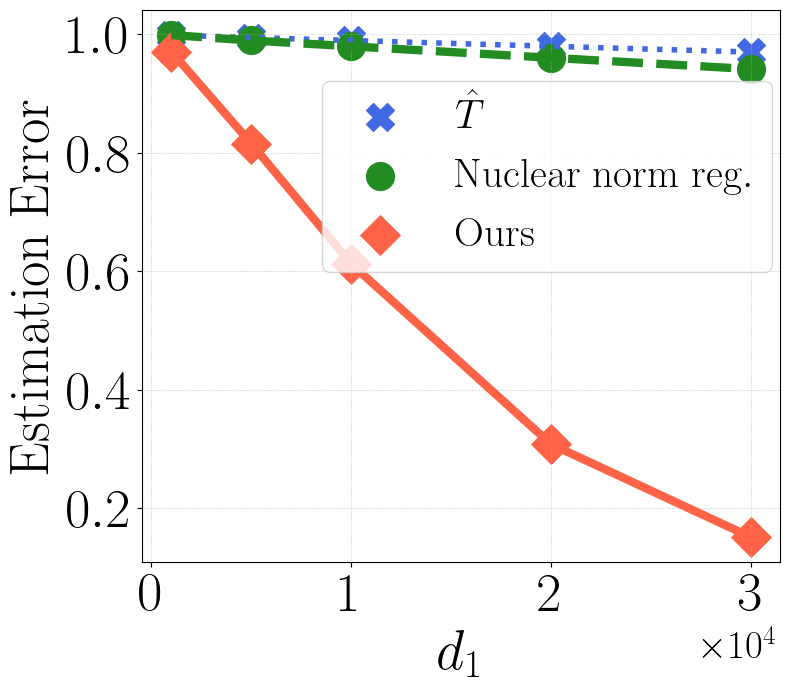

In [4]:
# title = r'$\mathrm{Synthetic~(2~obervations)}$'
X = results['user_list']
#xticks = [10000,  30000, 50000, 70000]
xticks = [1000, 5000, 10000, 20000, 30000]
print(X)


original_err_mean = results['original_err_mean']
original_err_std = results['original_err_std']
T_prob_err_mean = results['T_prob_err_mean']
T_prob_err_std = results['T_prob_err_std']
T_freq_err_mean = results['T_freq_err_mean']
T_freq_err_std = results['T_freq_err_std']
T_freq_rmse_mean = results['T_freq_rmse_mean']
T_freq_rmse_std = results['T_freq_rmse_std']
SVD_T_err_mean = results['SVD_T_err_mean']
SVD_T_err_std = results['SVD_T_err_std']

X_original_err_mean = results['X_original_err_mean']
X_original_err_std = results['X_original_err_std']

ob2_err_mean = results['ob2_err_mean']
ob2_rmse_mean = results['ob2_rmse_mean']

err_mean = results['err_mean']
err_std = results['err_std']
rmse_mean = results['rmse_mean']
rmse_std = results['rmse_std'] 

f, ax = plt.subplots(figsize=(8,7))

enhance = ob2_rmse_mean / rmse_mean
enhance = rmse_mean / ob2_rmse_mean
print(enhance.mean())
print(ob2_err_mean)
print(err_mean)
plt.plot(X, T_freq_err_mean, lw=4, color='royalblue',ls="dotted" )
plt.plot(X, ob2_err_mean, lw=6, color='forestgreen', ls="dashed")
plt.plot(X, err_mean, color='tomato',lw=6)

plt.scatter(X, T_freq_err_mean, s=400, color='royalblue', label=r"$\hat{T}$", marker="X")
plt.scatter(X, ob2_err_mean, s=400, color='forestgreen', label=r"$\mathrm{Nuclear~norm~reg.}$")
plt.scatter(X, err_mean, s=400, color='tomato', label=r"$\mathrm{Ours}$", marker="D")

plt.legend(fontsize=30, loc='upper right', bbox_to_anchor=(1.02, 0.91))

plt.xlabel(r"$d_1$", fontsize=40)
plt.ylabel(r"$\mathrm{Estimation~Error}$", fontsize=40)

xticks = [0, 10000, 20000, 30000]
plt.xticks(xticks, fontsize=40)
plt.ticklabel_format(style='sci', scilimits=(0,0), axis='x')
plt.yticks(fontsize=40)
ax.xaxis.get_offset_text().set_fontsize(28)

plt.grid(lw=0.5, ls=":")
plt.tight_layout()
plot_name = f"two_per_row_err.pdf"
plt.savefig(plot_name, bbox_inches='tight', format="pdf", dpi=1200)

plt.show()
plt.close()

[1000, 5000, 10000, 20000, 30000]


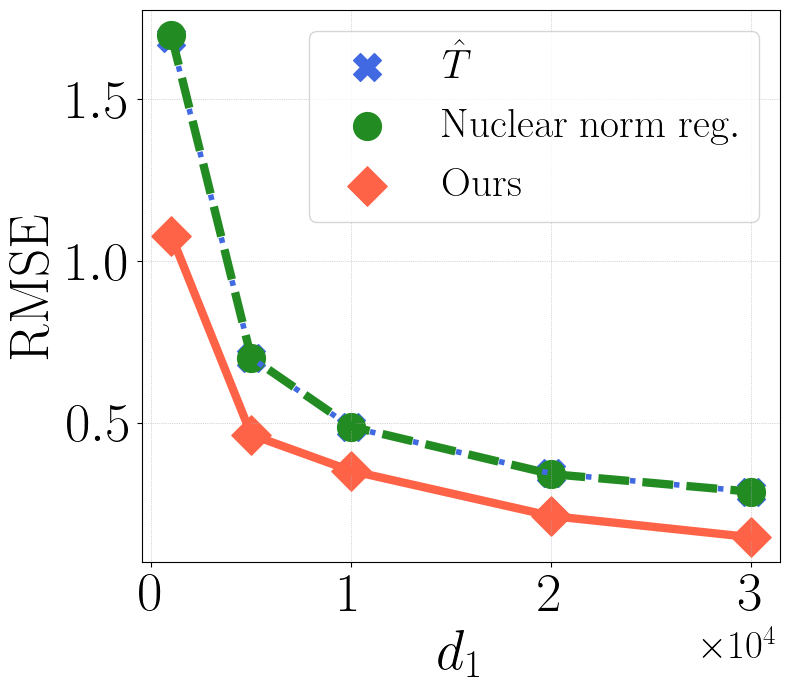

In [5]:
# observed entries
X = results['user_list']
#xticks = [10000, 30000, 50000, 70000]

print(X)

original_err_mean = results['original_err_mean']
original_err_std = results['original_err_std']
T_prob_err_mean = results['T_prob_err_mean']
T_prob_err_std = results['T_prob_err_std']
T_freq_err_mean = results['T_freq_err_mean']
T_freq_err_std = results['T_freq_err_std']

X_original_err_mean = results['X_original_err_mean']
X_original_err_std = results['X_original_err_std']

ob2_err_mean = results['ob2_err_mean']
ob2_rmse_mean = results['ob2_rmse_mean']

err_mean = results['err_mean']
err_std = results['err_std']
rmse_mean = results['rmse_mean']
rmse_std = results['rmse_std'] 

f, ax = plt.subplots(figsize=(8,7))

plt.plot(X, T_freq_rmse_mean, lw=4, color='royalblue',ls="dotted" )
plt.plot(X, ob2_rmse_mean, lw=6, color='forestgreen', ls="dashed")
plt.plot(X, rmse_mean, color='tomato',lw=6)

plt.scatter(X, T_freq_rmse_mean, s=400, color='royalblue', label=r"$\hat{T}$", marker="X")
plt.scatter(X, ob2_rmse_mean, s=400, color='forestgreen', label=r"$\mathrm{Nuclear~norm~reg.}$")
plt.scatter(X, rmse_mean, s=400, color='tomato', label=r"$\mathrm{Ours}$", marker="D")

plt.legend(fontsize=30, loc='upper right')

plt.xlabel(r"$d_1$", fontsize=40)
plt.ylabel(r"$\mathrm{RMSE}$", fontsize=40)

xticks = [0, 10000, 20000, 30000]
plt.xticks(xticks, fontsize=40)
plt.ticklabel_format(style='sci', scilimits=(0,0), axis='x')

ax.xaxis.get_offset_text().set_fontsize(28)

plt.yticks([0.5, 1.0, 1.5], fontsize=40)
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((4, 4))

plt.grid(lw=0.5, ls=":")
plt.tight_layout()
plot_name = f"two_per_row_rmse.pdf"
plt.savefig(plot_name, bbox_inches='tight', format="pdf", dpi=1200)

plt.show()
plt.close()